<a href="https://colab.research.google.com/github/manuelabarcarodriguez/Procesos-Gaussianos/blob/main/SimulacionGPs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Simulación Proceso Gaussiano

Un proceso gaussiano es un proceso esctocástico $\{ X_t \}_{t \in T}$ tomando generalmente $T=\mathbb{R}$ o un intervalo de $\mathbb{R}$. En este notebook vamos a ver ciertas simulaciones de este proceso estocástico.

In [1]:
# Importamos librerías básicas que utilizaremos

import numpy as np
import matplotlib.pyplot as plt
import math

## 1. Muestras de una normal multivariante / multidimensional

Puesto que simular trayectorias de un GP involucra simular de una normal multivariante, veamos primero cómo hacer esto.

En la siguiente celda se obtienen 50 muestras de una normal 3-dimensional $(X_1,X_2,X_3)$ que sigue una distribución normal $\mathcal{N}(0,I_{3\times 3})$


In [2]:

n=3 #tamano normal multivariante
vector_medias = np.zeros(n)
matriz_covarianzas = np.identity(n)
num_samples = 50
samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covarianzas, size=num_samples)

print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ 0.10909958  0.4229578   0.08249082]
 [ 0.15210838 -0.99549735 -0.31195405]
 [ 0.33364808  0.81787557  0.0254918 ]
 [-0.97382895  1.72337855  0.69285323]
 [-0.48700655 -0.41599015 -1.55256205]
 [-0.92805571 -1.09589932  0.28640535]
 [-0.21234166 -1.53661592  1.07172545]
 [-0.93568645  1.54233975  0.26710692]
 [ 0.60655339 -0.09480831  0.57556118]
 [ 1.27815171 -1.62991928 -0.36875716]
 [-0.62576884 -0.37834439  0.95513716]
 [ 2.25683689 -0.87464239 -1.11025417]
 [ 2.70131556 -0.72607002 -0.80868441]
 [-1.02895304 -1.26253928  0.98848603]
 [ 0.88678124  0.76313761 -1.17917291]
 [ 1.89313501  0.16268234 -0.81403558]
 [-0.40647473  0.50155047  0.22807575]
 [ 1.64458505  0.23361015  0.33693474]
 [ 0.07665206 -0.9052627   0.3145043 ]
 [ 1.30258204 -0.87801456  0.60064145]
 [-1.41161933 -0.14480652 -1.67166237]
 [-1.04052985 -1.04022432 -0.7896926 ]
 [-0.80913506  0.24225663  0.76034815]
 [ 1.89442816  0.03955883 -0.07099628]
 [-0.32295098 -0.14821919  0.36122435

Aquí hacemos lo mismo pero con la matriz$$\Sigma=\begin{pmatrix}1 & 0 & 0 \\
0 & 10 & 0 \\
0 & 0 & 100 \end{pmatrix}$$



In [3]:

n=3 #tamano normal multivariante
vector_medias = np.zeros(n)
valores = [1, 10, 100] #valores de la diagonal principal
matriz_covarianzas = np.diag(valores)
num_samples = 50
samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covarianzas, size=num_samples)
print("Shape: ", samples.shape)
print("Muestras: ")
print(samples)

Shape:  (50, 3)
Muestras: 
[[ -0.95502014  -2.44474022  -4.57284922]
 [  0.22694086   2.79134207  -4.96691411]
 [ -1.84960404  -7.0187596  -17.29301445]
 [  0.65199909  -2.39378589  34.63321759]
 [  0.32254584  -5.44172127  -1.15115634]
 [  2.52045426   4.08969915   0.8964472 ]
 [ -1.37586311   0.16004797   4.87589731]
 [  0.60600503   2.23763694   8.17017614]
 [  0.2810973   -1.79032698 -21.07072703]
 [  0.16306454  -1.20472081 -11.09068837]
 [ -0.03639026   1.62751512  -5.85719534]
 [  1.55659036   4.37642014  -2.95961499]
 [  0.80177788   3.23382839  15.4686886 ]
 [ -1.29585999  -0.79824603  10.89483789]
 [ -0.87324832  -5.18245893 -10.07913885]
 [  0.40142941  -1.02590479  17.85702695]
 [ -0.28402267   3.66541063  13.78537017]
 [  0.31147658   3.75662188  -2.30569446]
 [ -0.83102024   4.81444657 -12.84387295]
 [ -1.02305972  -1.56590099 -19.42369373]
 [ -0.34221708   1.94459939  -7.75558725]
 [  0.66549209   2.54406709  -5.34447492]
 [ -0.25856281  -3.02006194   4.20568608]
 [ -0.5

Un proceso gaussiano viene determinado por su función de medias y su kernel, las cuales nos permiten definir las distribuciones normales multivariantes para cada vector finito-dimensional que tomemos dentro de $T$. En general, para las funciones de medias no se impone ninguna restricción, pero para el kernel (el encargado de "generar" las matrices de covarianzas) debe verificar ciertas propiedades para que las matrices de covarianzas resultantes sean semidefinidas positivas y simétricas. Vamos a ver simulaciones con kernels comúnmente usados.

## 2. Simular un GP con kernel RBF

En esta sección vamos a definir una función `simular_GP_RBF` que nos permita simular de un GP con kernel RBF y con función de medias constante $0$. Este kernel tiene $2$ parámetros, el lengthscale, denotado por $l$, y sigma, que hace un papel similar a la varianza.


Definimos la función principal:

In [4]:

def simular_GP_RBF(t, sigma_sq=1, lengthscale=1, num_samples=1):
  #t es el vector de estados, sigma_sq es el parmetro sigma del proceso, y num_samples es el numero de trayectorias a simular


    vector_medias = np.zeros(np.size(t)) #definimos vector de medias
    #Como el kernel depende de la distancia al cuadrdo entre los estados, primero calculamos unaa matriz de la distncia entre todos los puntos
    dist_cuadrado = (t[:, np.newaxis] - t[np.newaxis, :])**2 #está restando por filas y por columnas, por lo que el resultado es una matriz n x n con todas las restas (distancias)
    matriz_covs = sigma_sq * np.exp(-((dist_cuadrado /  lengthscale)**2)*(1/2)) #formula del kernel RBF
    jitter = 1e-8 * np.eye(len(t)) #añadimos un jitter para evitar problemas con posibles errores de redondeo
    matriz_covs = matriz_covs  + jitter


    samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples)

    return samples

Usmaos esta función para simular diferentes tryectorias varaiando los parámetros.

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1106/2057403293.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
/tmp/ipykernel_1106/2057403293.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
/tmp/ipykernel_1106/2057403293.py:48: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
/tmp/ipykernel_1106/709756704.py:13: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples

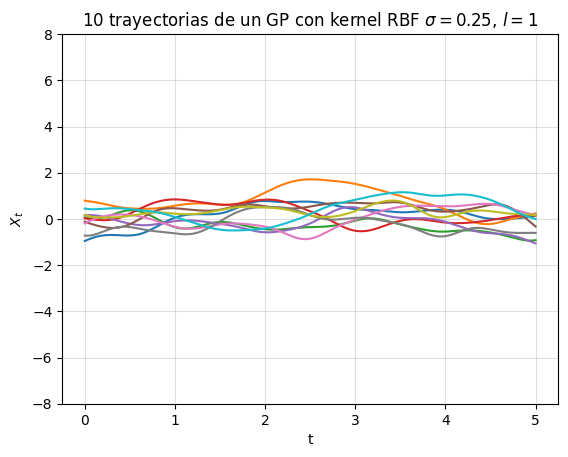

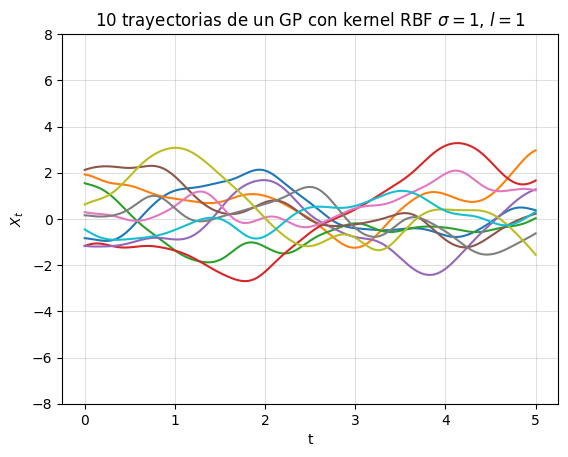

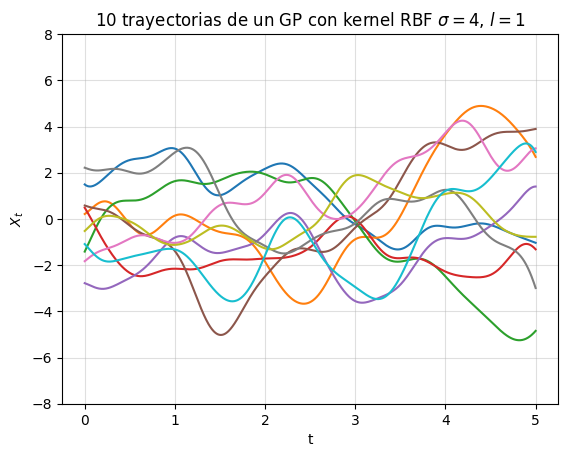

In [6]:
#Primera imagen

l = 1
sigma = 0.25
t = np.linspace(0, 5,1000)
n = 10 #numero dee trayectorias
samples = simular_GP_RBF(t,sigma,l,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :]) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
plt.ylim(-8, 8)
plt.show()
#Segunda imagen
l = 1
sigma = 1
t = np.linspace(0, 5,1000)
n = 10 #numero dee trayectorias
samples = simular_GP_RBF(t,sigma,l,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :]) #devuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
plt.ylim(-8, 8)
plt.show()

#Tercera imagen
l = 1 #lengthscale
sigma = 4 #varianza (al cuadrado)
t = np.linspace(0, 5,1000)
n = 10 #numero de trayectorias
samples = simular_GP_RBF(t,sigma,l,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :]) #devuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
plt.ylim(-8, 8)
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1106/2650327303.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
/tmp/ipykernel_1106/2650327303.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
/tmp/ipykernel_1106/2650327303.py:47: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
/tmp/ipykernel_1106/709756704.py:13: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples

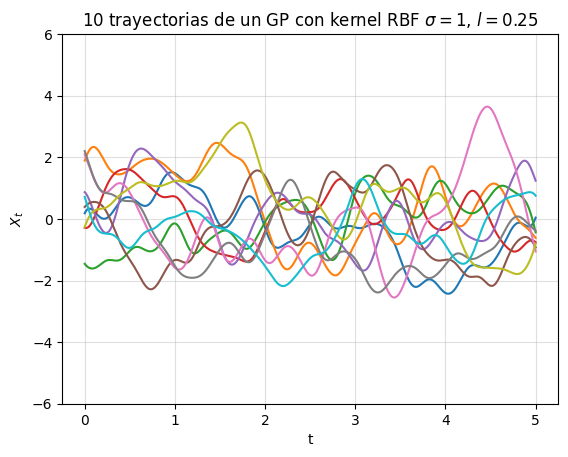

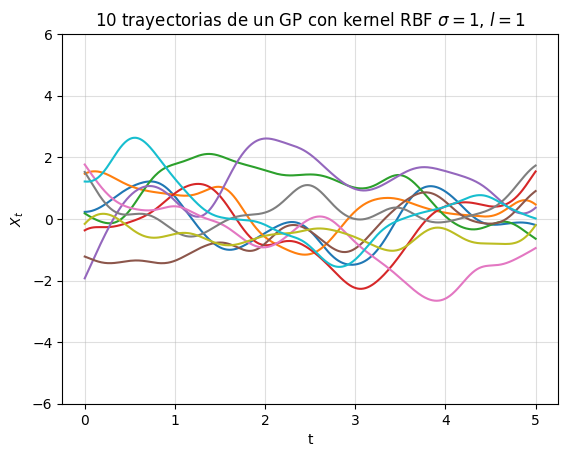

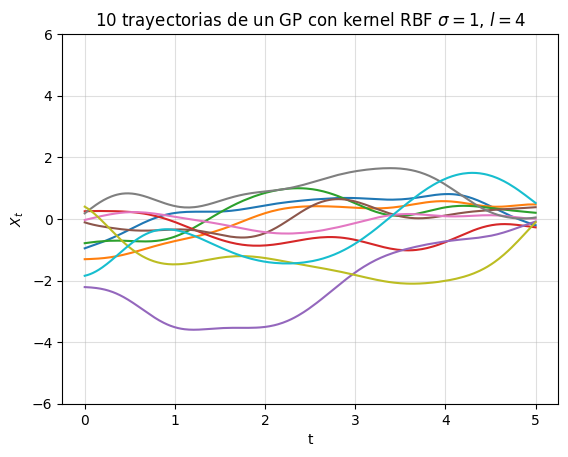

In [7]:
#Primera imagen
sigma = 1
l=0.25
t = np.linspace(0, 5,1000)
n = 10 #numero dee trayectorias
samples = simular_GP_RBF(t,sigma,l,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :]) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
plt.ylim(-6, 6)
plt.show()
#Segunda imagen
l = 1
sigma = 1
t = np.linspace(0, 5,1000)
n = 10 #numero dee trayectorias
samples = simular_GP_RBF(t,sigma,l,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :]) #devuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
plt.ylim(-6, 6)
plt.show()

#Tercera imagen
l = 4 #lengthscale
sigma = 1 #varianza (al cuadrado)
t = np.linspace(0, 5,1000)
n = 10 #numero de trayectorias
samples = simular_GP_RBF(t,sigma,l,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :]) #devuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con kernel RBF $\sigma={sigma}$, $l={l}$')
plt.ylim(-6, 6)
plt.show()

## 3. Simular un GP con kernel periódico

En esta sección vamos a hacer lo mismo que con el kernel RBF, pero esta vez tomndo el kernel periódico. En este caso hay que añdir el parámetro del periodo.

In [8]:
def simular_GP_periodic(t, sigma_sq=1, lengthscale=1,period=1, num_samples=1):



    vector_medias = np.zeros(np.size(t)) #vector de medias nulo

#de nuevo, calculamos la matriz de distancias (esta vez no al cuadrado)
    dist = (t[:, np.newaxis] - t[np.newaxis, :]) #está restando por filas y por columnas, por lo que el resultado es una matriz n x n con todas las restas (distancias)
    matriz_covs = sigma_sq * np.exp(-(2/lengthscale**2)*(np.sin(np.pi*(dist/period))**2)) #formula del kernel RBF
    jitter = 1e-8 * np.eye(len(t))
    matriz_covs = matriz_covs + jitter
    # Paso 3: obtén las muestras/simulaciones del GP. Utiliza la función vista antes: np.random.multivariate_normal
    samples = np.random.multivariate_normal(mean=vector_medias, cov=matriz_covs, size=num_samples)

    return samples

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1106/2859655789.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
/tmp/ipykernel_1106/2859655789.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')


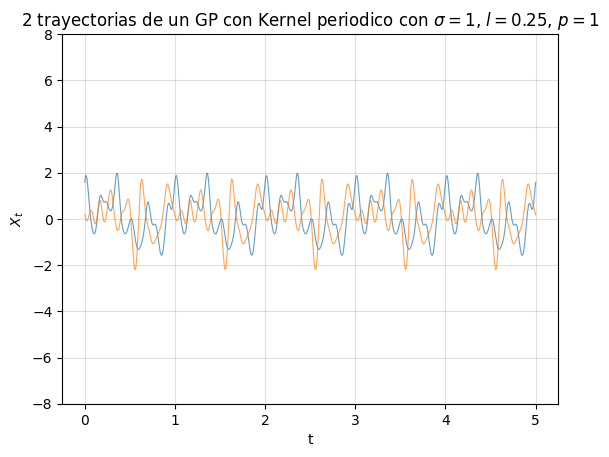

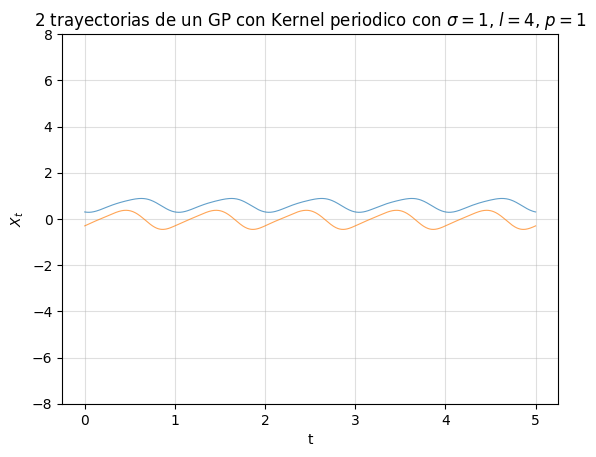

In [9]:
#Primera imagen
p=1
l = 0.25
sigma = 1
t = np.linspace(0, 5,1000)
n = 2 #numero dee trayectorias
samples = simular_GP_periodic(t,sigma,l,p,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
plt.ylim(-8, 8)
plt.show()
#Segunda imagen
p=1
l = 4
sigma = 1
t = np.linspace(0, 5,1000)
n = 2 #numero dee trayectorias
samples = simular_GP_periodic(t,sigma,l,p,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
plt.ylim(-8, 8)
plt.show()


<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1106/2736916526.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
/tmp/ipykernel_1106/2736916526.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')


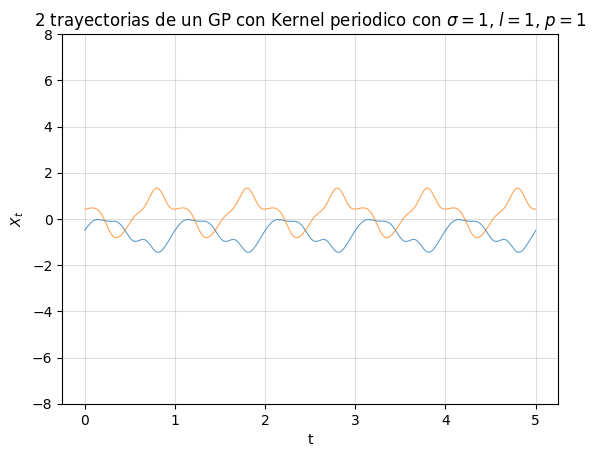

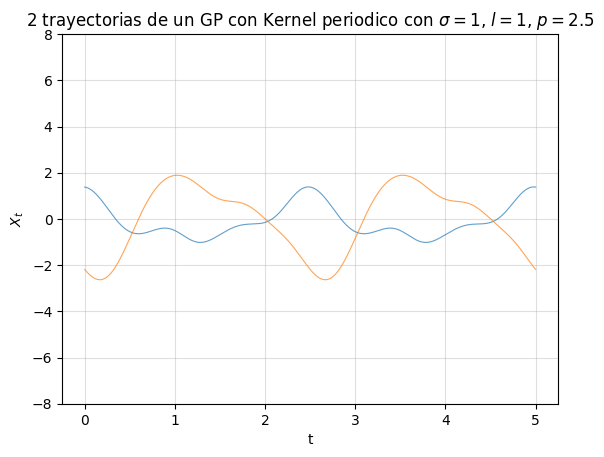

In [10]:
#Primera imagen
p=1
l = 1
sigma = 1
t = np.linspace(0, 5,1000)
n = 2 #numero dee trayectorias
samples = simular_GP_periodic(t,sigma,l,p,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
plt.ylim(-8, 8)
plt.show()
#Segunda imagen
p=2.5
l = 1
sigma = 1
t = np.linspace(0, 5,1000)
n = 2 #numero dee trayectorias
samples = simular_GP_periodic(t,sigma,l,p,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
plt.ylim(-8, 8)
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1106/3968619188.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
/tmp/ipykernel_1106/3968619188.py:32: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')


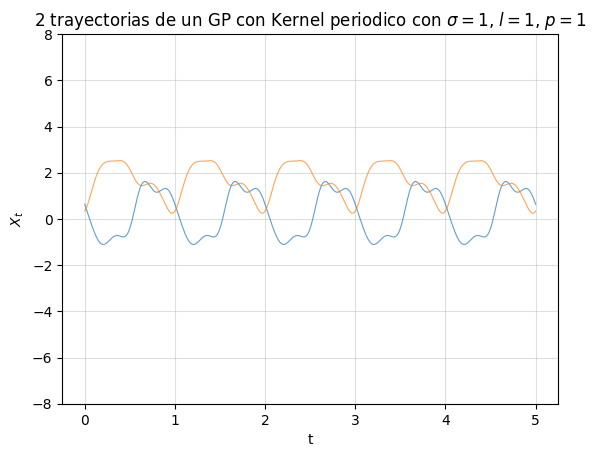

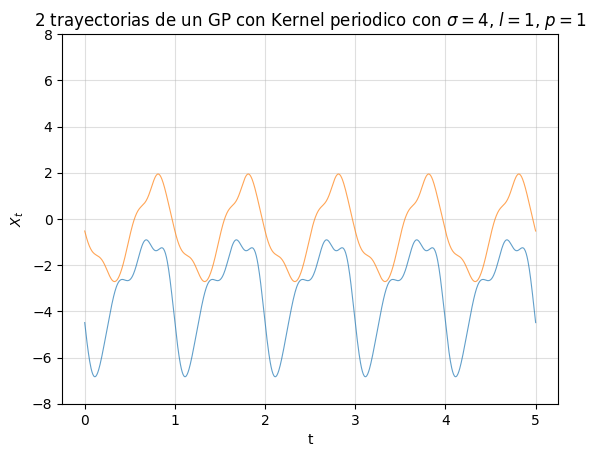

In [11]:
#Primera imagen
p=1
l = 1
sigma = 1
t = np.linspace(0, 5,1000)
n = 2 #numero dee trayectorias
samples = simular_GP_periodic(t,sigma,l,p,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
plt.ylim(-8, 8)
plt.show()
#Segunda imagen
p=1
l = 1
sigma = 4
t = np.linspace(0, 5,1000)
n = 2 #numero dee trayectorias
samples = simular_GP_periodic(t,sigma,l,p,n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel periodico con $\sigma={sigma}$, $l={l}$, $p={p}$')
plt.ylim(-8, 8)
plt.show()

## 4. Simular un GP con kernel DPK (concretamente, polinómico hasta grado $m$)

En esta sección vamos a hacer lo mismo que venimos haciendo pero con un kernel DPK (dot product kernel) y función de medias nula. Para usar este kernel debemos usar una lista de funciones "base", que vamos a tomar los monomios $\{1,t,t^2,...,t^m\}$, donde $m$ lo vamos a tomar como parámetro.

In [12]:
import numpy as np

def simular_GP_DPKpoly(t, m=1, num_samples=1):

    exponentes = np.arange(m + 1) #creamos el vector de exponentes de los monomios (vector 0,1,...,m)

    F = t[:, np.newaxis] ** exponentes[np.newaxis, :] #creamos la funcion F con el valor de los monomios t^i con el fin de muestrar una Normal N(0,F*Ftraspuesta)

    matriz_covs = F @ F.T #el @es la multiplicacion de matrices


    vector_medias = np.zeros_like(t)


    jitter = 1e-8 * np.eye(len(t)) #añadimos un jitter para evitar posibles problemas

    samples = np.random.multivariate_normal(vector_medias, matriz_covs + jitter, size=num_samples) #muestreo

    return samples



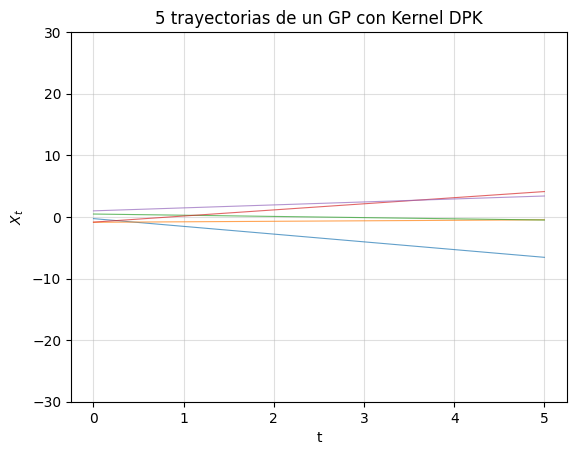

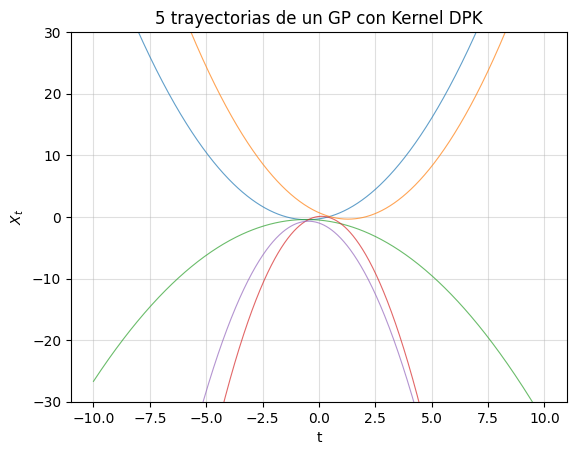

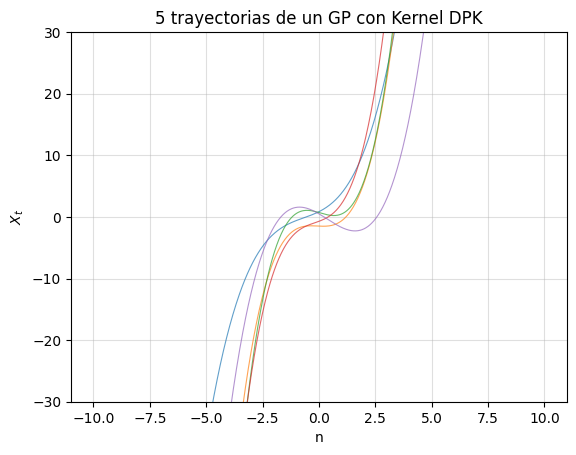

In [13]:
#Primera imagen
t = np.linspace(0, 5,1000)
m= 1
n = 5 #numero dee trayectorias
samples = simular_GP_DPKpoly(t, m, n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel DPK')
plt.ylim(-30, 30)
plt.show()

#Segunda imagen
t = np.linspace(-10, 10,1000)
m= 2
n = 5 #numero dee trayectorias
samples = simular_GP_DPKpoly(t, m, n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('t')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel DPK')
plt.ylim(-30, 30)
plt.show()

#Tercera imagen
t = np.linspace(-10, 10,1000)
m= 3
n = 5 #numero de trayectorias
samples = simular_GP_DPKpoly(t, m, n)
for i in range(0,n,1): #por cada repeticion genera una trayectoria
    plt.plot(t,samples[i, :], alpha=0.7, linewidth=0.8) #tdevuelve la fila i-esima

#Retoques esteticos
plt.xlabel('n')
plt.ylabel(r'$X_t$')
plt.grid(True, alpha=0.4)
plt.title(f'{n} trayectorias de un GP con Kernel DPK')
plt.ylim(-30, 30)
plt.show()

